In [ ]:
import gymnasium as gym
from gymnasium_env import BlokusEnv
from src.agents.agent import Agent, RandomAgent, SimpleFunctionAgent, MiniMaxAgent, QL_Agent
from gymnasium_env.envs.single_agent_blokus_env import SingleAgentBlokusEnv

# GreedyAgent, MCTSAgent, MCTSAgent2
import numpy as np
from tqdm import tqdm
import pickle
import cProfile

/Users/mario/Documents/proj/cam/Blokus/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:642: UserWarning: WARN: Overriding environment gymnasium_env/Blokus-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [2]:
random = RandomAgent()
opponent = MiniMaxAgent(name="minimax", depth=2, board_size=7)
env = SingleAgentBlokusEnv(board_size=7, num_players=2, render_mode="console", mode = "good", hidden_agents=[None, None, opponent], player_turn=1)

Neighborhood to encoded actions loaded
Initialised on good mode
Cache not found for MiniMaxAgent with depth 2 and board size 7
Initialised on good mode


In [5]:
import numpy as np
from tqdm import tqdm
import pickle
import cProfile
import subprocess
import os
from src.utils import encode_board_string, decode_board_string

q_table = {}

alpha = 0.01  # Learning rate
# min_alpha = 0.01
gamma = 0.995  # Discount factor
epsilon = 1.0  # Exploration rate
epsilon_decay = 0.9995
min_epsilon = 0.01

ql_agent = QL_Agent(
    name="ql_agent",
    q_table_path="against_minimax2.pkl",
    alpha=alpha,
    gamma=gamma,
    epsilon=epsilon,
    epsilon_decay=epsilon_decay,
    min_epsilon=min_epsilon
)
random_agent = RandomAgent(name="random_agent")
agent = random_agent
    
def create_q_table(state: str, actions: np.ndarray):
    if state not in q_table:
        q_table[state] = {action: 0 for action in actions}

def get_q_value(state: str, action: int) -> float:
    return q_table[state][action]

def set_q_value(state: str, action: int, value: float):
    q_table[state][action] = value

def argmax(state: str) -> int:
    return max(q_table[state], key=q_table[state].get)

def maxi(state: str) -> float:
    if len(q_table[state].values()) == 0:
        return 0
    return max(q_table[state].values())

a = 0
win_accuracy = 70
random_agent = RandomAgent(name="random_agent")
agent = random_agent
freq = [0] * 1000
def main(num_episodes = 250000):
    global a
    # Initialize Q-table
    env.render_mode = "console"

    # Hyperparameters
    
    beta = (1 / (alpha * 10)) ** (1 / 5)
    print(f"beta: {beta}")

    win_counter, tie_counter, lose_counter = 0, 0, 0

    # Q-learning algorithm
    pbar = tqdm(range(num_episodes))
    win_rate = []
    tie_rate = []
    loss_rate = []
    last_win_counter = 0
    try:
        states_before = len(env.hidden_agents[2].cache)
    except:
        states_before = 0
    for i in pbar:
        # pbar.set_description(f"Episode {i+1}: Wins: {win_counter}, Ties: {tie_counter}, Losses: {lose_counter}, Epsilon: {epsilon:.4f}")
        obs, info = env.reset()
        state = encode_board_string(obs["state"])
        done = False
        create_q_table(state, obs["possible_actions"])
        total_reward = 0
        while not done:
            action = agent.get_action(env, obs)
            next_obs, reward, terminated, truncated, info = env.step(action)
            freq[len(next_obs["possible_actions"])] += 1
            next_state = encode_board_string(next_obs["state"])
            obs = next_obs
            # Update Q-table
            create_q_table(next_state, next_obs["possible_actions"])
            total_reward += reward
            estimated_reward = reward + gamma * maxi(next_state)
            lr_scale = beta ** np.clip(-estimated_reward, -1, 5)
            # q_table[state, action] = q_table[state, action] + alpha * (reward + gamma * np.max(q_table[next_state]) - q_table[state, action])
            # if done:
            #     if total_reward > 0:
            #         reward1 = reward + 5
            #     elif total_reward == 0:
            #         reward1 = reward - 10
            #     else:
            #         reward1 = reward - 100
            # else:
            #     if total_reward + maxi(next_state) > 0:
            #         reward1 = reward + 2
            #     elif total_reward + maxi(next_state) == 0:
            #         reward1 = reward - 2
            #     else:
            #         reward1 = reward - 20
            agent.set_q_value(state, action, agent.get_q_value(state, action) + alpha * lr_scale * (reward + gamma * (1 - done) * agent.maxi(next_state) - agent.get_q_value(state, action)))
            done = terminated or truncated
            state = next_state
            if terminated:
                if total_reward > 0:
                    win_counter += 1
                elif total_reward == 0:
                    tie_counter += 1
                else:
                    lose_counter += 1
            
            if truncated:
                print("Truncated")
                assert False
        if (i + 1) % 100 == 0:
            last_win_counter = win_counter
            try:
                cache_size = len(env.hidden_agents[2].cache)
            except:
                cache_size = 0
            pbar.set_description(f"E {i+1}: W: {win_counter}, T: {tie_counter}, L: {lose_counter}, ε: {epsilon:.4f}, S: {len(q_table)}, Cache: {cache_size}")
            win_counter = 0
            tie_counter = 0
            lose_counter = 0
        if i < num_episodes - 100 + 1:
            epsilon = max(min_epsilon, epsilon * epsilon_decay)
            # alpha = max(min_alpha, alpha * epsilon_decay)
        else:
            epsilon = 0
    global win_accuracy
    agent.save_q_table()
    print(f"Q-table saved with accuracy {last_win_counter}")
    try:
        states_after = len(env.hidden_agents[2].cache)
        env.save_caches()
        print(f"States discovered: {states_after - states_before}")
        # print(states_before, states_after)
    except Exception as e:
        print(e)
        pass
        
    

    win_accuracy = last_win_counter
    if last_win_counter > 80:
        print("Win rate above 95%")
    else:
        # main(num_episodes)
        a += 1

# cProfile.run("main()", sort=  "cumtime")

In [6]:
import pstats

try:
    # Run the profiler
    cProfile.run("main(20)", "profile_output")
finally:
    # Create a Stats object
    p = pstats.Stats("profile_output")

    # Set the precision for the output
    p.strip_dirs().sort_stats("cumtime").print_stats()

    # Print the stats with custom formatting
    for func in p.fcn_list:
        stats = p.stats[func]
        ncalls = stats[0]
        tottime = stats[2]
        percall = tottime / ncalls if ncalls else 0
        cumtime = stats[3]
        filename = func[0]
        lineno = func[1]
        funcname = func[2]
        print(f"{ncalls:>8} {tottime:>8.3f} {percall:>8.3f} {cumtime:>8.3f} {percall:>8.8f} {filename}:{lineno}({funcname})")

    print(a)

beta: 1.5848931924611136


100%|██████████| 20/20 [00:00<00:00, 115.50it/s]


Q-table saved with accuracy 0
'SingleAgentBlokusEnv' object has no attribute 'agent'
Mon Dec 16 16:55:40 2024    profile_output

         277541 function calls (276795 primitive calls) in 0.918 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
       26    0.000    0.000    0.691    0.027 base_events.py:1915(_run_once)
        1    0.000    0.000    0.541    0.541 <string>:1(<module>)
        1    0.000    0.000    0.541    0.541 2677964905.py:51(main)
        1    0.538    0.538    0.540    0.540 {built-in method _pickle.dump}
       99    0.000    0.000    0.238    0.002 single_agent_blokus_env.py:16(step)
       66    0.000    0.000    0.210    0.003 agent.py:120(get_action)
   620/37    0.013    0.000    0.206    0.006 agent.py:147(minimax)
    29/27    0.001    0.000    0.169    0.006 {method 'run' of '_contextvars.Context' objects}
      767    0.002    0.000    0.130    0.000 blokus_env.py:522(step)
     1646    0.00

Last index different from 0: 233
[]


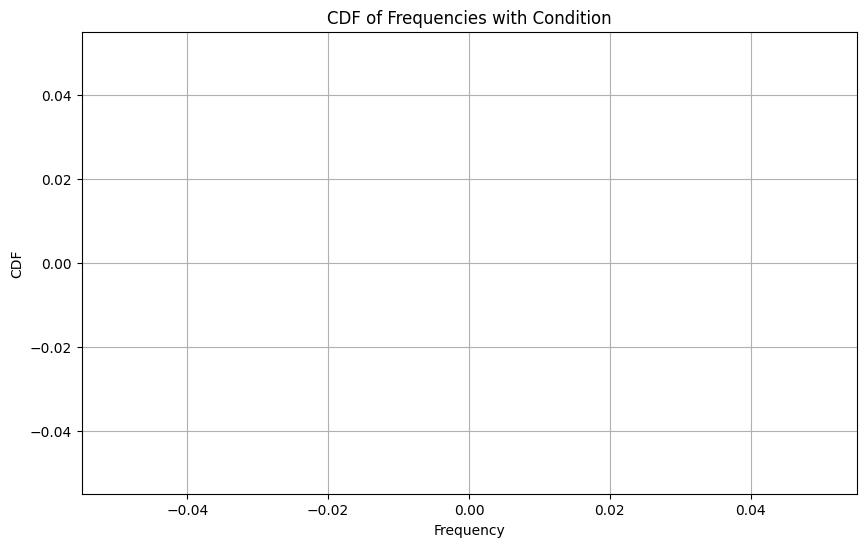

In [5]:
# display freq
# states_after = len(env.agent.cache)
import matplotlib.pyplot as plt

# print(freq)
freq = np.array(freq)
last_non_zero_index = 233
print(f"Last index different from 0: {last_non_zero_index}")
# Plot the frequency distribution
# plt.figure(figsize=(10, 6))
# l, r = 0, 234
# plt.bar(range(l, r), freq[l: r], color='blue')
# plt.xlabel('State Length')
# plt.ylabel('Frequency')
# plt.title('Frequency Distribution of State Lengths')
# plt.grid(True)
# plt.show()

def plot_cdf_with_condition(f):
    indices = [x for x in range(1000) if f(x)]
    print(indices)
    plt.figure(figsize=(10, 6))
    plt.plot(indices, freq[indices], marker='.', linestyle='none')
    plt.xlabel('Frequency')
    plt.ylabel('CDF')
    plt.title('CDF of Frequencies with Condition')
    plt.grid(True)
    plt.show()

plot_cdf_with_condition(lambda x: freq[x] > 2500)
# # print(f"States discovered: {states_after - states_before}")
# env.agent.save_cache()
# print(states_after)
# with open(AGENT_NAME, 'wb') as f:
#     pickle.dump(q_table, f)

In [6]:
# print(env.agent.cache)

In [1]:
import random
from src.agents.agent_heuristics import greedy

q_table = {}
def encode_board(board: np.ndarray) -> str:
    return ''.join(map(str, board.flatten()))

def decode_board(encoded_board : str, n: int) -> np.ndarray:
    board = []
    board = np.zeros((n, n), dtype=int)
    for i in range(n):
        for j in range(n):
            board[i, j] = int(encoded_board[i * n + j])
    return board

def create_q_table(state: str, actions: np.ndarray):
    if state not in q_table:
        q_table[state] = {action: 0 for action in actions}
    
def get_q_value(state: str, action: int) -> float:
    return q_table[state][action]

def set_q_value(state: str, action: int, value: float):
    q_table[state][action] = value

not_visited = 0
def argmax(state: str) -> int:
    if not state in q_table:
        global not_visited
        not_visited += 1
        return -1
    return max(q_table[state], key=q_table[state].get)

def maxi(state: str) -> float:
    if len(q_table[state].values()) == 0:
        return 0
    return max(q_table[state].values())

# AGENT_NAME = 'q_table6.pkl'
agent = QL_Agent(name = "ql_agent", q_table_path="against_minimax2.pkl")
# with open(AGENT_NAME, 'rb') as f:
#     q_table = pickle.load(f)
agent.epsilon = 0
random_agent1 = RandomAgent()
greedy_agent1 = SimpleFunctionAgent(name="hey", func=greedy)
helper_agent = random_agent1
# opponent_agent = gree
random_agent = RandomAgent()
greedy_agent = SimpleFunctionAgent(name="hey", func=greedy)
minimax_agent = MiniMaxAgent(name="minimax", depth=2, board_size=7)
env.agent = greedy_agent
# env.render_mode = "human"
env.render_mode = "console"
num_states = 0
def test_agent(env, num_episodes=100):
    global q_table
    win_counter, tie_counter, lose_counter = 0, 0, 0
    global num_states
    for _ in range(num_episodes):
        obs, info = env.reset()
        state = encode_board(obs["state"])
        done = False
        total_reward = 0

        while not done:
            num_states += 1
            action = agent.get_action(env, obs)
            if action == -1:
                action = helper_agent.get_action(env, obs)
            next_obs, reward, terminated, truncated, info = env.step(action)
            next_state = encode_board(next_obs["state"])
            state = next_state
            obs = next_obs
            total_reward += reward
            done = terminated or truncated
            # env.render()
        if total_reward > 0:
            win_counter += 1
        elif total_reward == 0:
            tie_counter += 1
        else:
            lose_counter += 1

    return win_counter, tie_counter, lose_counter

print(get_q_value("0" * 49, 58))
print(argmax("0" * 49))

win_counter1 = np.zeros(1000)
tie_counter1 = np.zeros(1000)
lose_counter1 = np.zeros(1000)
# Test the agent
prange = tqdm(range(1000))
for i in prange:
    win_counter1[i], tie_counter1[i], lose_counter1[i] = test_agent(env)
    prange.set_description(f"W: {win_counter1[:i+1].mean():.3f}, T: {tie_counter1[:i+1].mean():.3f}, L: {lose_counter1[:i+1].mean():.3f}, NV: {not_visited / (num_states) * 100:.3f}%")

print(f"Number of not visited states: {not_visited}")

/Users/mario/Documents/proj/cam/Blokus/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:642: UserWarning: WARN: Overriding environment gymnasium_env/Blokus-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


NameError: name 'np' is not defined

Number of win_counter less than 75: 236


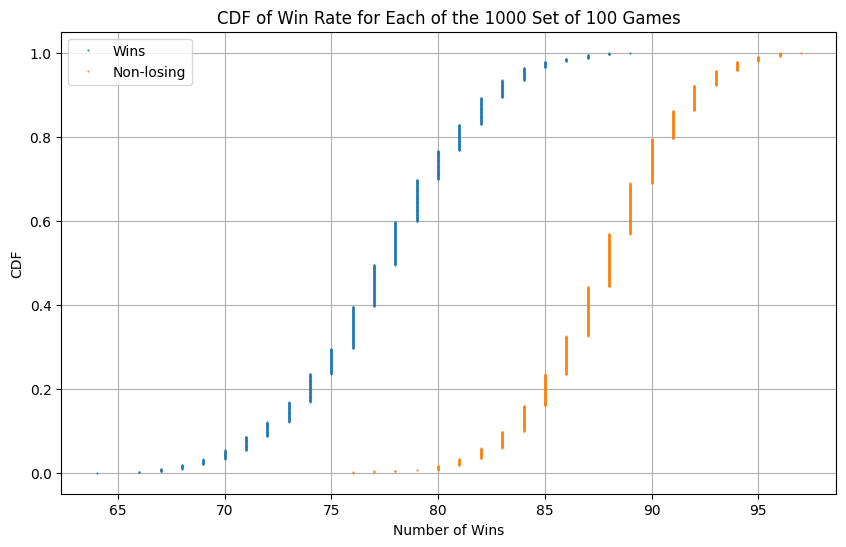

In [9]:
import matplotlib.pyplot as plt

win_counter = win_counter1
tie_counter = tie_counter1
lose_counter = lose_counter1
non_losing_counter = win_counter + tie_counter
# Calculate the CDF
win_counter_sorted = np.sort(win_counter)
cdf = np.arange(1, len(win_counter_sorted) + 1) / len(win_counter_sorted)

# Plot the CDF for wins
plt.figure(figsize=(10, 6))
plt.plot(win_counter_sorted, cdf, marker='.', linestyle='none', label='Wins', markersize=1)
plt.xlabel('Number of Wins')
plt.ylabel('CDF')
plt.title('CDF of Win Rate for Each of the 1000 Set of 100 Games')
plt.grid(True)

num_wins_less_than_75 = np.sum(win_counter < 75)
print(f"Number of win_counter less than 75: {num_wins_less_than_75}")

# Calculate and plot the CDF for non-losing counter
non_losing_counter_sorted = np.sort(non_losing_counter)
cdf_non_losing = np.arange(1, len(non_losing_counter_sorted) + 1) / len(non_losing_counter_sorted)
plt.plot(non_losing_counter_sorted, cdf_non_losing, marker='.', linestyle='none', label='Non-losing', markersize=1)

plt.legend()
plt.show()

In [10]:
print(sum(win_counter),sum(non_losing_counter))

77436.0 87844.0
